# Week 4: NumPy

<img src="img/numpy_logo.png" width=200>

##### by **2025/2026 LearnX+ Python Studio**

## Course Learning Outcomes

By the end of this notebook, you will be able to:

i. Initialize arrays to represent data using different methods

ii. Understand computational efficiency (structure and memory)

iii. Manipulate arrays through slicing, indexing and reshaping

iv. Perform fast vectorized operations on array

v. Compute linear algebra problem, e.g. matrix operations, solve systems of linear equations, and compute eigenvalues/eigenvectors

vi. Perform statistical analysis on data

vi. Simulate physical systems using random number generation.

**Main references**

<img src="img/book.png" height=400>

## 1 Introduction to NumPy

As a physics student, you are going to spend a lot of time describing the physical world using math. 

Whether you are 
- modeling the trajectory of a projectile, 
- calculating the energy states of a quantum harmonic oscillator, or 
- analyzing data from a lab experiment, 

you will eventually hit a wall: doing these calculations by hand is **too slow** and sometimes there is even **no analytic solution**.

This is where **Computational Physics** comes in, and the foundational tool for scientific computing in Python is `NumPy` (**Numerical Python**).

<img src="img/numpy.png" alt="NumPy" width="400">

#### A Brief History of NumPy: Unifying Scientific Python

Before NumPy existed, the Python scientific community was fragmented. In the late 90s and early 2000s, there were two competing libraries for handling large numerical arrays: `Numeric` and `Numarray`. This split meant that different scientific packages couldn't easily talk to each other.

In 2006, a developer named Travis Oliphant merged the best features of both into a single, unified library: `NumPy`. Today, NumPy is the undisputed bedrock of the Python scientific ecosystem. Libraries we will use later like `SciPy` (for advanced physics formulas), `Pandas` (for data analysis), and `Matplotlib` (for graphing) are all built directly on top of NumPy.

<img src="img/travis_oliphant.png" alt="NumPy" width="400">

#### Why NumPy? And Why Not Standard Python?

You might be wondering: Python already has lists that can hold numbers. Why do we need a whole new library?

The short answer is **Speed** and **Memory**, due to NumPy utilising **contiguous memory** and **vectorisation**, and is written in **C-language**.

We will discuss how can it been achieved in the next section. 

#### `ndarray` object

The core **object** in NumPy is the `ndarray`, a multidimensional array of a single data type which can be 
- sorted,
- reshaped, 
- subject to mathematical operations and statistical analysis
- written to and read from files, and much more. 

<img src="img/ndarray.png" width="400">

An `ndarray` is very similar to a mathematical vector or matrix.

1D array as vector:
$$
\begin{pmatrix}
    7 & 2 & 9 & 10
\end{pmatrix}
$$

2D array as matrix:
$$
\begin{pmatrix}
    5.2 & 3.0 & 4.5 \\
    9.1 & 0.1 & 0.3
\end{pmatrix}
$$


In fact, we will use `ndarray`s to represent them and solve related linear algebra problems.

Main advantages of using `ndarray` over native Python list:
- Very fast, as they are implemented as precompiled `C` code
- Supports vectorisation, where a single operation can be carried out on an entire array

<img src="img/performances.png" width="500">

Source: https://www.reddit.com/r/Python/comments/gcucwl/why_one_should_always_use_numpy_arrays_over/

### Let's get started!

Run the following command in your terminal to install NumPy

`conda activate myenv`

`conda install numpy`

`conda install matplotlib`

Once installed, you may import NumPy by:

In [3]:
import numpy as np

### 1.1 `ndarray` creation

There are several ways to create an ndarray

`np.array` constructor

In [4]:
a = np.array([1, 2, 3, 4])

b = np.array([[0, 0], [1, 1]])

print(a, '\n')
print(b)

[1 2 3 4] 

[[0 0]
 [1 1]]


If we **do not know the element values** at the time of creation, there are several methods to declare an array of a particular shape filled with arbitrary default values.

In [6]:
np.empty((2,2))

# The array contains garbage data of whatever values happened to be in the allocated memory at that time.

array([[0., 0.],
       [0., 0.]])

In [8]:
np.zeros((3,2))

array([[0., 0.],
       [0., 0.],
       [0., 0.]])

In [9]:
np.ones((3))

array([1., 1., 1.])

#### Initializing an array from a sequence


`np.arange` is the NumPy equivalent of Python `range`, but it can generate `float` sequences

In [10]:
print(np.arange(5))
print(np.arange(1.5, 3, 0.5) )

[0 1 2 3 4]
[1.5 2.  2.5]


`np.linspace` generate an **evenly spaced** array, with the last element included

In [16]:
np.linspace(0, 20, 10)

array([ 0.        ,  2.22222222,  4.44444444,  6.66666667,  8.88888889,
       11.11111111, 13.33333333, 15.55555556, 17.77777778, 20.        ])

`retstep` argument returns the step size

In [18]:
x, dx = np.linspace(0, 20, 10, retstep=True)

dx

np.float64(2.2222222222222223)

#### Initializing an array from a function

In [19]:
def f(i, j):
    return i+j
    
np.fromfunction(f, (3,3))

array([[0., 1., 2.],
       [1., 2., 3.],
       [2., 3., 4.]])

In [22]:
np.fromfunction(lambda i,j: i**2 + j**2, (4,3))

array([[ 0.,  1.,  4.],
       [ 1.,  2.,  5.],
       [ 4.,  5.,  8.],
       [ 9., 10., 13.]])

### 1.2 `ndarray` attributes

In [21]:
a = np.array([[1,2,3],
              [4,5,6]])

print(a.shape)  # (rows, columns)

print(a.ndim)   # number of dimensions (rank)

print(a.size)   # total number of elements

(2, 3)
2
6


### 1.3 NumPy data types (`dtype`s)

Unlike Python default `list` object, which may have objects of different data type stored in a list, NumPy constrains each `ndarray` to have a unique data type.

The is necessary to interface with the underlying compiled C code the elements of a NumPy array must be stored in a compatible format, that is each element is represented in a **fixed number of bytes** that are interpreted in a particular way.

In contrast, Python memory is dynamically assigned for the variables as required by their size.

<img src="img/data_type.png" width="500"/>


In [24]:
a = np.array([1,2,3])

print(a.dtype)  # the array's data type

print(a.data)   # the buffer in memory containing the actual elements of the array (in hexadecimal)

int64


We can explicitly set the data type using the optional `dtype` argument.

In [25]:
np.zeros((2,2), dtype='u4')     # 4-byte (32-bit) integers

array([[0, 0],
       [0, 0]], dtype=uint32)

In [26]:
np.array([1,2,'3+j'], dtype='complex')

array([1.+0.j, 2.+0.j, 3.+1.j])

<img src="img/data_type_str.png" width="500"/>

### 1.4 ***Universal functions*** (`ufunc`s) and Vectorisation

NumPy provides many mathematical functions that the `math` module does, implemented as **universal functions** that act on each element of an array, returning an array without explicitly using loop.

Universal functions are the way NumPy allows for **vectorisation**, which gives clean and efficient code.

In [27]:
x = np.linspace(1,5,5)

print(x)

print(x + 1)    
print(x**2)    
print(np.sqrt(x))
print(np.sin(x))

[1. 2. 3. 4. 5.]
[2. 3. 4. 5. 6.]
[ 1.  4.  9. 16. 25.]
[1.         1.41421356 1.73205081 2.         2.23606798]
[ 0.84147098  0.90929743  0.14112001 -0.7568025  -0.95892427]


In [28]:
y = np.exp(-np.linspace(0,2,5))

print(np.sin(x-y))

[ 0.          0.98431873  0.48771645 -0.59340065 -0.98842844]


NumPy array multiplication ($*$) is defined **elementwise**

$$
\begin{pmatrix}
    1 & 2 \\ 3 & 4
\end{pmatrix}

\circ

\begin{pmatrix}
    1 & 0 \\ 0 & 1
\end{pmatrix}

=

\begin{pmatrix}
    1\times 1 & 2\times 0 \\ 3\times 0 & 4\times 1
\end{pmatrix}

=
\begin{pmatrix}
    1 & 0 \\ 0 & 4
\end{pmatrix}

$$

In [29]:
a = np.array([[1,2], 
              [3,4]])

b = np.array([[1,0],
              [0,1]])

a*b

array([[1, 0],
       [0, 4]])

Matrix multiplication is implemented by `.dot` function

In [30]:
a.dot(b)

array([[1, 2],
       [3, 4]])

Comparison and logic operators are also vectorised
| Operators | Symbols | 
|---|---|
| not | $\sim$ | 
| and | $\&$ | 
| or | $\|$ |

In [31]:
a = np.linspace(1,5,5) ** 2 

print(a)
print(a > 20)   
print((a < 8) | (a > 20))  # True if the element is <8 OR >20

[ 1.  4.  9. 16. 25.]
[False False False False  True]
[ True  True False False  True]


### 1.5 Special values `nan` and `inf`

`np.nan` is an object represents the output of a ill-defined/ indeterminate mathematical operation, e.g. $0/0$, $0^0$

`np.inf` is an object represents infinity. e.g. $1/0$

In [33]:
a = np.arange(0,4)
print(a)

a = a / 0
print(a)

[0 1 2 3]
[nan inf inf inf]


/var/folders/b2/740w22v56jnf6sm71673gg9w0000gn/T/ipykernel_79427/3100771246.py:4: RuntimeWarning: divide by zero encountered in divide
  a = a / 0
/var/folders/b2/740w22v56jnf6sm71673gg9w0000gn/T/ipykernel_79427/3100771246.py:4: RuntimeWarning: invalid value encountered in divide
  a = a / 0


Use `np.isnan` and `np.isinf` to test if the elements are `nan` of `inf`

In [34]:
print(np.isnan(a))
print(np.isinf(a))
print(np.isfinite(a))

[ True False False False]
[False  True  True  True]
[False False False False]


`nan` is neither finite nor infinite

### $\color{cyan}{\text{Quiz}}$

To simulate a pendulum's motion,
$$
\theta(t) = A\cos{\left(\sqrt{\frac{g}{l}}t\right)}
$$

Let $A= 10^\circ$, $l = 1m$, $g=10 m/s^2$

Create a 100 data points array for time $t$, starting at $t=0$ and ending exactly at $t=10$ seconds, and another array for their corresponding angle values $\theta (t)$.

In [36]:
# Write your solution here
t = np.linspace(0, 10, 100)

theta = 10 * np.cos(np.sqrt(10/1 * t))

print(theta)

[10.          5.36056292  1.48902412 -1.69162867 -4.25287303 -6.26096172
 -7.77721825 -8.85831887 -9.55656143 -9.92012162 -9.9932971  -9.81674005
 -9.42767849 -8.86012696 -8.14508684 -7.31073687 -6.38261419 -5.38378628
 -4.33501421 -3.25490764 -2.16007166 -1.06524615  0.01656227  1.07395531
  2.09702475  3.07724062  4.00734555  4.88125491  5.69396265  6.44145248
  7.12061409  7.72916439  8.26557329  8.72899404  9.1191977   9.43651178
  9.68176259  9.85622142  9.96155407  9.99977379  9.97319739  9.88440424
  9.7361983   9.5315727   9.27367703  8.96578692  8.61127608  8.21359042
  7.77622434  7.30269889  6.79654181  6.26126941  5.70036994  5.11728869
  4.51541442  3.89806727  3.26848792  2.62982798  1.98514155  1.33737782
  0.68937472  0.04385349 -0.59658591 -1.2294685  -1.85244721 -2.46330523
 -3.05995752 -3.64045181 -4.20296907 -4.74582335 -5.26746124 -5.76646085
 -6.24153035 -6.69150625 -7.11535122 -7.51215171 -7.88111525 -8.22156751
 -8.53294915 -8.81481252 -9.06681809 -9.28873086 -9

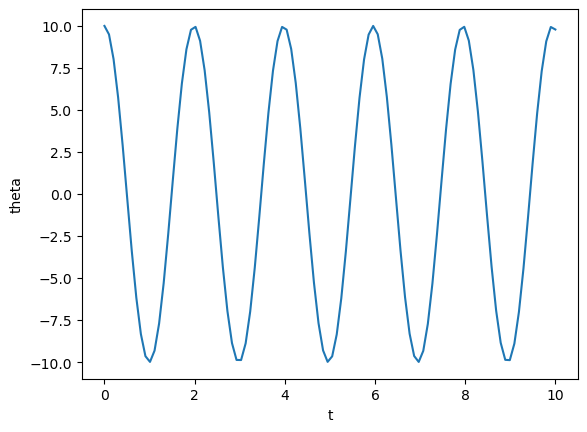

In [39]:
# Solution

import matplotlib.pyplot as plt

A = 10
l = 1  # noqa: E741
g =10

t = np.linspace(0,10,100)

th = A * np.cos(np.sqrt(g/l) * t)

plt.xlabel('t')
plt.ylabel('theta')
plt.plot(t, th)
plt.show()

## 2 Structure of `ndarray`s and Contiguous Memory

### `ndarray` structure

An `ndarray` is composed of two parts:
- Raw data buffer:  A single, continuous block of memory containing the actual numerical value.
- Metadata:
    - Data type: e.g. `int32`
    - Shape: e.g. (2,2)
    - Strides: The number of bytes to "skip" in memory to get to the next element in a row or column

<img src="img/metadata.png" width=600>

https://commons.wikimedia.org/wiki/

<img src="img/data_structure.png" width=600>

https://i.sstatic.net/EeBUb.png

### Contiguity

Memory is **contiguous** when the elements are stored one after the other in a single, uninterrupted block in computer's RAM.

Because RAM is linear (1D), a multi-dimensional array must be *flattened* to fit into memory. There are two primary ways to do this:
- row major order (C-style)
$$
\begin{pmatrix}
    1 & 2 & 3\\
    4 & 5 & 6
\end{pmatrix}

\longrightarrow

\begin{pmatrix}
    1 & 2 & 3 & 4 & 5 & 6
\end{pmatrix}
$$

- column-major order (Fortran-style)

$$
\begin{pmatrix}
    1 & 2 & 3\\
    4 & 5 & 6
\end{pmatrix}

\longrightarrow

\begin{pmatrix}
    1 & 4 & 2 & 5 & 3 & 6
\end{pmatrix}
$$


An `ndarray`s are stored in memory in **row-major order**.



In [40]:
a = np.array([[1,2,3],
              [4,5,6]])

a.flatten()

array([1, 2, 3, 4, 5, 6])

### Why contiguity?

- When the CPU needs a piece of data, it doesn't just grab one byte, it grabs a whole chunk of data and puts it in its high-speed cache. The next time you ask for a value of the same array, it's already in the cache.

- Python lists, however, are "arrays of pointers", which store addresses to objects scattered over memory (non-contiguous), making them slow.

- For some operations, like `.T` (transpose) is nearly instantaneous. NumPy doesn't move any data, it just changes the metadata.

The fact that items are stored contiguously in memory allows NumPy to take advantage of vectorized instructions of modern CPUs. For example, multiple consecutive floating point numbers can be loaded in 128, 256, or 512 bits registers for vectorized arithmetical computations implemented as CPU instructions.

This explains why NumPy arrays computation is so efficient.

### Strides and Memory Address

NumPy uses a **pointer** to the very first element and then calculates an offset.

If we want the element at a certain position, NumPy calculates how many steps (bytes) it needs to jump forward from the start to reach that specific data point.

It calculates the memory address of an element at `(i, j)` by:
$$\text{Address} = \text{Base Address} + (i \times \text{stride}_0) + (j \times \text{stride}_1)$$

#### Example


Consider a $2\times 3$ array $\begin{pmatrix}
    1 & 2 & 3\\
    4 & 5 & 6
\end{pmatrix}$,

If the pointer want to find the $[1, 2]$ element ($6$):
- $1$ element takes $8$ bytes ($64$ bits)

- To move down $1$ row, jump $3$ elements x $8$ bytes/element =  $24$ bytes (row stride)

- To move $1$ column, jump $1$ elements x $8$ bytes/element =  $8$ bytes (column stride)

- Address of $[1,2]$ = Base address + $1$ x $24$ + $2$ x $8$ = Base address + $40$ bytes.

NumPy jumps 20 bytes from the start of the array and finds the number 6.

In [ ]:
print(a)
print('Data type:', a.dtype) # 8 bytes (64 bits) per element
print('Shape:', a.shape)
print('Stride:', a.strides)

## 3 Manipulating Arrays

### 3.1 Changing the Shape of an Array

There are two methods to "flatten" a multidimensional array onto a single axis: `.flatten` and `.ravel`. Both flatten the array into its internal ordering (row-major), as discussed.

$$
\begin{pmatrix}
    1 & 2 & 3\\
    4 & 5 & 6
\end{pmatrix}

\longrightarrow

\begin{pmatrix}
    1 & 2 & 3 & 4 & 5 & 6
\end{pmatrix}
$$

`flatten` return an independent copy of the element, but is slower.

In [41]:
a = np.array([[1,2,3], [4,5,6], [7,8,9]])

b = a.flatten() # create an independent, flattened copy
print(b)

b[3] = 0
print(b)    # b has been changed
print(a)    # but a remain unchanged

[1 2 3 4 5 6 7 8 9]
[1 2 3 0 5 6 7 8 9]
[[1 2 3]
 [4 5 6]
 [7 8 9]]


`ravel` return an object references the elements of the original array. It does not own its data elements.

In [42]:
c = a.ravel()
print(c)

c[3] = 0
print(c)
print(a)    # 4 also changes to 0

[1 2 3 4 5 6 7 8 9]
[1 2 3 0 5 6 7 8 9]
[[1 2 3]
 [0 5 6]
 [7 8 9]]


`resize` resize an array to a new compatible shape.

In [48]:
a = np.arange(4)

print(a)

a.resize(2,2)   # changes the metadata, but doesn't return anything

print(a)

[0 1 2 3]
[[0 1]
 [2 3]]


Resizing to a larger shape pads with zeros.

In [45]:
a.resize(3,2)
print(a)

[[0 1]
 [2 3]
 [0 0]]


Resizing to a smaller shape is allowed only if it doesn't reference another array's data, and doesn't have references to it.

In [49]:
b = a
b.resize(5,1)

ValueError: cannot resize an array that references or is referenced
by another array in this way.
Use the np.resize function or refcheck=False

`reshape` returns a view on the array with its elements reshaped as required. The original array is not modified.

In [50]:
a.reshape(4,1) 

array([[0],
       [1],
       [2],
       [3]])

In [52]:
a

array([[0, 1],
       [2, 3]])

<img src="img/reshape.png" width=600>

Source: numpy.org

`transpose` returns a view of an array with the axes transposed.

For a 2D array, it's the matrix transpose.

In [53]:
a = np.linspace(1,6,6).reshape(3,2)

print(a, '\n')
print(a.transpose(), '\n')
print(a.T)

[[1. 2.]
 [3. 4.]
 [5. 6.]] 

[[1. 3. 5.]
 [2. 4. 6.]] 

[[1. 3. 5.]
 [2. 4. 6.]]


### 3.2 Merging and Spliting arrays

There are a few methods that merge and split arrays in different ways.

`vstack`, `hstack`, and `dstack` stack arrays vertically, horizontally and depthwise, respectively.

In [ ]:
a = np.array([0,0,0,0])
b = np.array([1,1,1,1])
c = np.array([2,2,2,2])

print(np.vstack((a,b,c)), '\n')
print(np.hstack((a,b,c)), '\n')
print(np.dstack((a,b,c)), '\n')


Note that the array created contains an **independent copy** of the data from the original arrays.

In [ ]:
a = np.arange(4)

print(a, a.T)   # 1D array's transpose is the same shape as the original

In [ ]:
a = np.ones((3,3))

print(np.vstack((a, np.array([2,2,2]))), '\n')
print(np.hstack((a, np.array([2,2,2]).reshape(3,1))))   # reshape instead of transpose

The inverse operations, `vsplit`, `hsplit` and `dsplit` split a single array into multiple arrays by rows, columns or depth.
- These methods require an argument indicating how to split the array.
- It returns **view** on the original data.

In [ ]:
a = np.arange(6)

print(np.hsplit(a, 3), '\n')

print(np.hsplit(a, (1,3,5)))    # the array is split on those indexes, same as [a[:1], a[1:3], a[3:5], a[5:]]

### 3.3 Indexing and Slicing an Array

An array is indexed by a tuple of integers. Slicing and striding is supported in the same way as well, using `[start:stop:step]`.
- The ending index is excluded.

For 1D arrays there is only one index:

In [ ]:
a = np.arange(10)

print(a)
print(a[1:5:2])     # a[1] and a[3], a[5] is excluded
print(a[5::-2])     # a[5], a[3] and a[1], stride (step) = -2

Multidimensional arrays have an index for each axis. To select every item along a particular axis, replace its index with a **colon**:

In [ ]:
a = np.linspace(1,12,12).reshape(4,3)

print(a, '\n')

print(a[3,1])
print(a[2,:])   # everything in row 2
print(a[:,1])   # everything in column 1

print('\n')
print(a[1:-1, 1:])  # -1 means until the last row

<img src="img/array_slicing.png" width="500"/>

In [ ]:
a[:, 1] = 0     # : works for values assignment
a[1, :] = [100, 200, 300]
print(a)

<img src="img/slicing.png" width=500>

Source: geeksforgeeks.org/numpy-indexing/

The **ellipsis** notation (`...`) is useful for high-rank arrays: in an index, it represents as many colons as are necessary to represent the remaining axes. 

For example, for a four-dimensional array, 
- `a[3, 1, ...]` is equivalent to `a[3, 1, :, :]` 
- `a[3,...,1]` is equivalent to `a[3, :, :, 1]`

#### Integers arrays indexing

NumPy arrays can also be indexed by arrays of integers and tuples of tuples. Such indexing creates a new array with its own copy of the data, rather than a view.

In [ ]:
a = np.linspace(2, 12, 6)   # 1D array

print(a)

print(a[[1, 3, 4]], '\n')     
# creates a 1D array from a 1D array: [ a[1], a[3], a[4] ]

ia = np.array([[1,2], [3,4]])
print(a[ia])
# creates a 2D array from a 1D array:
# [ a[1], a[2]
#   a[3], a[4] ] 

In [ ]:
a = np.linspace(1,12,12).reshape(4,3)   # 2D array

print(a, '\n')

ia = np.array([[1,0], [2,1]])
ja = np.array([[0,1], [1,2]])

print(a[ia, ja])

# creates a 2D array from a 2D array
# [ a[1,0], a[2,1]
#   a[0,1], a[1,2] ]

#### Boolean array indexing

It is also possible to use an array of boolean values to index an array. 
The True elements of this indexing array identify elements in the target array to be returned:

In [ ]:
a = np.array([-2,-1,0,1,2])
ia = np.array([False, True, False, True, True])

print(a[ia])


Comparisons (e.g. `<`, `==`) and boolean operations (e.g. `&`, `|`, `~`) gives boolean value, this leads to a very useful shortcuts to manipulate an array

In [ ]:
print(a < 0)

print(a[a < 0])

a[a>0] = 0
print(a)

### $\color{cyan}{\text{Quiz}}$

A **leap year** occurs every 4 years to align the calendar with the Earth's orbit, adding a day (Feb 29) to make a 366-day year. 

A year is a leap year if 
- it is divisible by 4
- except for century years (divisible by 100)
- except it is divisible by 400.

Check which of the following years are leap years: $1900, 1904, 1993, 2000, 2014, 2100$

In [ ]:
# Write your solution here


In [ ]:
# Solution
years = np.array([1900, 1904, 1993, 2000, 2014, 2100])  
leap_year = (years % 400 == 0) | (years % 4 == 0) & ~(years % 100 == 0)     # array of boolean value

print("Leap years:", years[leap_year])

print(np.array(list(zip(years, leap_year))))

### 3.4 Adding an axis

When slicing, add a `np.newaxis` tells NumPy to add a new axis (dimension) of size 1 right there.

This is useful when we want to increase the dimensionality of the array by **exactly one**.

- 0D (Scalar) → 1D (Vector): `5` becomes `[5]`

- 1D (Vector) → 2D (Matrix): `[1, 2, 3]` becomes `[[1, 2, 3]]` or `[[1], [2], [3]]`

- 2D (Matrix) → 3D (Tensor): A 3×3 square becomes a cube with a depth of 1.

In [ ]:
a = np.array([1,2,3])
print(a, '\n')

b = a[np.newaxis, :]
print(b)
print('Shape:', b.shape, '\n')      # a 2D row vector

c = a[:,np.newaxis]
print(c)
print('Shape:',c.shape)     # a 2D column vector

Technically, `np.newaxis` is just an alias for `None` object

In [ ]:
type(np.newaxis)

In [ ]:
a[:,None]

### 3.5 Sorting an array

#### `sort`
NumPy arrays can be sorted in several different ways with the `sort` method, which orders the numbers in an array in place. 

In [ ]:
a = np.array([5, -1, 2, 4, 0, 4])
a.sort()

a

By default, this method sorts multidimensional arrays along their **last axis**. 

In [ ]:
b = np.array([[0, 3, -2], [7, 1, 3], [4, 0, -1]])
print(b)

b.sort()    # sort the numbers along each row (axis=1)
print(b)

To sort along some other axis, set the axis argument.

In [ ]:
b.sort(axis=0)  # sort the numbers along each column
print(b)

The sorting algorithm used is the “quicksort” algorithm, a good general-purpose algorithm. 

Some arrays can be sorted faster with the alternative mergesort or heapsort algorithms. These can be selected by setting the optional `kind` argument.

<img src="img/sorting.png" width=500>

Source: https://medium.com/@kaustubhdwivedi1729/when-to-use-which-sorting-algorithm-125897e40295

Further reading: https://en.wikipedia.org/wiki/Sorting_algorithm

#### `np.argsort`

To get the indexes of the sorted array rather than the sorted elements themselves, we could use `np.argsort`.

In [ ]:
a = np.array([3, 0, -1, 1])

np.argsort(a)

The `argsort` method can be combined with the previously discussed integer array indexing to sort an array.

In [ ]:
a[np.argsort(a)]

`np.argsort` also takes the axis and kind arguments 

#### `np.searchsorted`

`np.searchsorted` takes a sorted array and one or more values, and returns the indexes in the sorted array at which the values should be entered to maintain its order.

In [ ]:
a = np.array([1, 2, 3, 4])
np.searchsorted(a, 3.5)

In [ ]:
np.searchsorted(a, (3.5, 0, 1.1))

## 4 Operations on Arrays

### 4.1 Boardcasting

Broadcasting is a set of **rules** in NumPy that allows to perform arithmetic operations, like addition and multiplication, between `ndarray`s of different shapes.

NumPy compares the shapes of the two arrays starting from the rightmost dimension and moving left.

Two array dimensions are compatible only if:
- They are equal, OR
- One of them is 1, which may be considered to be a one-dimensional array of length 1

For 1D,

In [ ]:
a = np.array([1,2,3])   # shape: (3)
b = np.array([2,2,2])

# pointwise multiplication
print(a * b)    # shape: (3) x (3) -> (3)

# scalar multiplication
print(a * 3)    # shape: (3) x (1) -> (3)

For 2D, arrays are compatible only if:
- The length of the rightmost dimension are equal, OR
- One of them is (1).

In [ ]:
a = np.array([[1,2,3],
              [4,5,6]])     # shape: (2,3)

b = np.array([-1,-2,-3])    # shape: (3)

# pointwise multiplication by row
print(a * b)    # shape: (2,3) * (3) -> (2,3) * (1,3) -> (2,3)

# scalar multiplication
print(a * 10)   # shape: (2,3) * (1) -> (2,3) * (1,1) -> (2,3)

In [ ]:
c = np.array([[-1],
              [-2]])

print(c * a)    # shape: (2,1) * (2,3) -> (2,3)

In [ ]:
a = np.array([1,2,3])
b = np.array([0,10,100])

# outer product
c = a[:,None] * b   # shape: (3,1) * (3) -> (3,3)
d = a[:,None] * b[None,:]   # shape: (3,1) * (1,3) -> (3,3)

print(c, '\n')
print(d)

#### Why boardcasting?

Broadcasting is more efficient than Python loop:

- Speed: The looping happens in optimized C code, making it significantly faster than a Python `for` loop.

- Memory: NumPy doesn't actually create a new large array in your RAM. It simulates the array "stretching", the "broadcasting" of the smaller array across the larger one so they have compatible shapes for element-wise math., during the calculation.

$$
\begin{pmatrix}
    1 & 2 & 3\\
    4 & 5 & 6
\end{pmatrix} 
* 2
\xrightarrow{\text{Boardcasting}}
\begin{pmatrix}
    1 & 2 & 3\\
    4 & 5 & 6
\end{pmatrix} 
*
\begin{pmatrix}
    2 & 2 & 2\\
    2 & 2 & 2
\end{pmatrix} 
= 
\begin{pmatrix}
    2 & 4 & 6\\
    8 & 10 & 12
\end{pmatrix} 
$$

$$
\text{Note:} *\text{denotes pointwise multiplication}
$$


(Quick quizes on the boardcasting rules)

### $\color{cyan}{\text{Quiz}}$

**Question 1**: You have two arrays with the following shapes:

- Array A: (3,4)
- Array B: (4,)

Will the operation A + B work? If so, what is the resulting shape?

---

**Question 2**: Which of the following pairs of array shapes CANNOT be broadcast together?

- (A) (5,3) and (3,)

- (B) (8,1,6) and (8,12,1)

- (C) (2,1) and (8,4)

- (D) (1,7) and (5,7)

---

**Question 3**: If you add a column vector of shape (3,1) to a row vector of shape (1,3), what is the shape of the resulting matrix?

**Solution**

Q1 Answer: (3,4)

Following the right-to-left rule: The trailing dimensions are both 4 (Match!). Array A then has a 3, while Array B has nothing left (effectively a 1). The result is (3,4).

--- 

Q2 Answer: C. 

Let's compare (2,1) and (8,4).
- Rightmost: 1 vs 4 (Compatible, 1 expands to 4).
- Next dimension: 2 vs 8 (Incompatible! Neither is 1 and they aren't equal).

---
Q3 Answer: (3,3)

This is a classic broadcasting trick used to create grids. The (3,1) expands to (3,3) and the (1,3) expands to (3,3). The result is a 3×3 matrix containing every possible sum of the elements.

### 4.2 Meshes

To evaluate a multidimensional function on a grid of points (scalar field such as temperature field), a mesh is useful in the sense of fast vectorized calculation of functions over a grid.

The function `np.meshgrid` is passed a series of N one-dimensional arrays representing coordinates along each dimension and returns a **tuple of N-dimensional arrays** comprising a mesh of coordinates at which the function can be evaluated.

<img src="img/temperature_field.png" width=500>

<img src="img/meshgrid.png" width=500>

In [ ]:
x = np.array([1, 2, 3])
y = np.array([10, 20])

X, Y = np.meshgrid(x, y)

print(X)
print(Y)

If we want to calculate a function like $z=x^2+y^2$ for every point on the grid, with meshgrid we can just do the following instead of `for` loop

In [ ]:
Z = X**2 + Y**2

Z

Note: The default indexing is in `'xy'` (Cartesian) mode, the first output corresponds to the columns and the second to the rows. This matches how we think of (x,y) graphs

But it can be confusing if we expect the first array to be the first dimension of the matrix. We can change the indexing parameter to `'ij'` (matrix) mode

In [ ]:
x = np.array([1, 2, 3])
y = np.array([10, 20])

X, Y = np.meshgrid(x, y, indexing='ij')

print(X)
print(Y)

Z = X**2 + Y**2

print(Z)

e.g. If we want to know what does $3^2+20^2$ equal to, we can use the indices in the computed matrix to look it up. (`x[2]=3`, `y[1]=20`)

In [ ]:
Z[2,1]

#### Example: Contour plot

In [ ]:
import matplotlib.pyplot as plt

x = np.linspace(-3, 3, 100)
y = np.linspace(-3, 3, 100)
X, Y = np.meshgrid(x, y)

Z = X**2 + Y**2   # CHANGE TO ANY FUNCTION

fig, ax = plt.subplots()
cp = ax.contourf(X, Y, Z, levels=20, cmap='viridis') # Filled contours
fig.colorbar(cp) # Add color scale

line_contours = ax.contour(X, Y, Z, colors='black', alpha=0.5)
ax.clabel(line_contours, inline=True, fontsize=8)

plt.show()

### 4.3 Logic and Comparisons

NumPy provides a set of methods for comparing and performing logical operations on arrays elementwise.

<img src="img/logical_operations.png" width="600"/>

`np.any()` returns True if at least one element in the array evaluates to True. 

`np.all()` returns True only if all elements in the array evaluate to True.

Non-zero numbers are considered True, while zero is considered False.

In [ ]:
a = np.array([[1, 2, 0, 3], [4, 0, 1, 1]])

np.any(a), np.all(a)

`np.isreal` and `np.iscomplex` return boolean arrays

In [ ]:
b = np.array([1, -1j, 0.5j, 0, 1-2.5j])
np.isreal(b)

Since the representation of floating point numbers is not exact, comparing two float arrays with the `==` operator is not always reliable.

Instead, the best we can do is see if two values are “close” to one another within some absolute or relative tolerance.

NumPy provides `np.isclose(a, b)` for elementwise comparisons of two arrays: it returns True for elements satisfying

$$\text{abs}(a-b) \leq (\text{atol} + \text{rtol} * \text{abs}(b))$$


with absolute tolerance, atol and relative tolerance, rtol which are $10^{-8}$ and $10^{−5}$ respecively by default and can be changed.

In [ ]:
a = np.array([1.66e-27, 1.38e-23, 6.63e-34, 6.02e23, np.nan])
b = np.array([1.66e-27, 1.66e-27, 1.66e-27, 6.00e23, np.nan])

np.isclose(a, b)

In [ ]:
np.isclose(a, b, equal_nan=True)

`allclose(a, b)` returns a **single** value: True only if every element in `a` is equal to the corresponding element in `b` within the tolerance, and otherwise False.

In [ ]:
x = np.linspace(0, np.pi, 100)

np.allclose(np.sin(x)**2, 1 - np.cos(x)**2)

The example above applies `allclose` method to check if all values of $\sin^2{x}$ and $1-\cos^2{x}$ are equal in the domain $0\leq x \leq \pi$.

## 5 Linear Algebra

### 5.1 Vectors and Matrices Operations

Although NumPy provides a `matrix` class that specializes ndarray to make linear algebra calculations easier and can be used to represent vectors, for many purposes it is just as convenient to define a vector with n components as a regular one-dimensional array with n elements, or a matrix with a **two-dimensional NumPy array**. 

In addition to elementwise operations such as vector addition and subtraction, NumPy array objects implement dot product, cross product, matrix multiplication, elementwise multiplication, transpose...

#### Dot product or Inner product

Let
$$
\mathbf{a} = (a_1, a_2, \cdots, a_n) \quad \quad \mathbf{b} = (b_1, b_2, \cdots, b_n)
$$

The dot (inner) product of $a$ and $b$ is defined as

$$
\mathbf{a} \cdot \mathbf{b} = \sum_{i=1}^{n}{a_i b_i} = a_1 b_1 + a_2 b_2 + \cdots + a_n b_n
$$

In [54]:
a = np.array([1, 0, -3])    # vector as a one-dimensional array
b = np.array([2, -2, 5])    

print(a.dot(b))    # or b.dot(a) or np.dot(a,b)
print(b.dot(a))
print(np.dot(a,b))

-13
-13
-13


In [55]:
print(np.inner(a,b))

-13


#### Cross product

$$
\mathbf{a} \times \mathbf{b} = 
\begin{vmatrix}
\mathbf{i} & \mathbf{j} & \mathbf{k} \\
a_1 & a_2 & a_3 \\
b_1 & b_2 & b_3
\end{vmatrix}
$$

Note that we can only take the cross product of an array with three elements.

In [56]:
np.cross(a,b)

array([ -6, -11,  -2])

To use dot and cross on two individual vectors, ensure that they are **row vectors** and not column vectors represented as an (n,1) array.

In [57]:
a = np.array([[1], [0],[-3]]) 
b = np.array([[2],[-2], [5]])

np.dot(a,b)

ValueError: shapes (3,1) and (3,1) not aligned: 1 (dim 1) != 3 (dim 0)

To take the dot product or cross product of two column vectors, they need to be **flattened** into row vectors.

In [58]:
np.dot(a.flatten(), b.flatten()) 

np.int64(-13)

Alternatively, we can also use `ravel.()` or `transpose.()`

#### Outer product

The outer product of two coordinate vectors is the matrix whose entries are **all products** of an element in the first vector with an element in the second vector.

$$
\mathbf{a} \otimes \mathbf{b} = \mathbf{a} \mathbf{b}^\top = 
\begin{pmatrix}
a_1 b_1 & a_1 b_2 & \dots \\
a_2 b_1 & a_2 b_2 & \dots \\
\vdots & \vdots & \ddots
\end{pmatrix}
$$

For example
$$
\begin{pmatrix}
1 \\ 2
\end{pmatrix}

\otimes 

\begin{pmatrix}
3 \\ 4
\end{pmatrix}

= 

\begin{pmatrix}
1 \times 3 & 1 \times 4\\
2 \times 3 & 2 \times 4
\end{pmatrix}

=

\begin{pmatrix}
3 & 4 \\
6 & 8
\end{pmatrix}

$$

In [59]:
np.outer(a,b)

array([[  2,  -2,   5],
       [  0,   0,   0],
       [ -6,   6, -15]])

#### Scalar multiplication of matrix

In [60]:
A = np.array([[0, 0.5], 
              [-1, 2]])

A * 5

array([[ 0. ,  2.5],
       [-5. , 10. ]])

#### Matrix multiplication

Let matrices

$$
A = (a_{ij}), \quad B = (b_{ij})
$$
The matrix multiplication of $A$ and $B$ is defined as

$$
(AB)_{ij} = \sum_{k=1}^{n} a_{ik}b_{kj}
$$

In [61]:
B = np.array([[2, -0.5], 
              [3, 1.5]])

A.dot(B)

array([[1.5 , 0.75],
       [4.  , 3.5 ]])

#### Elementwise multplication

In [62]:
A * B

array([[ 0.  , -0.25],
       [-3.  ,  3.  ]])

#### Transpose of a matrix

$$ (A^\mathsf{T})_{ij} = A_{ji} $$

e.g. 

$$
A = \begin{bmatrix}
1 & 2 & 3 \\
4 & 5 & 6
\end{bmatrix}
\implies
A^\mathsf{T} = \begin{bmatrix}
1 & 4 \\
2 & 5 \\
3 & 6
\end{bmatrix}
$$


In [63]:
print(A.transpose())

# or
print(A.T)

[[ 0.  -1. ]
 [ 0.5  2. ]]
[[ 0.  -1. ]
 [ 0.5  2. ]]


#### Elementwise exponentiation

In [65]:
A

array([[ 0. ,  0.5],
       [-1. ,  2. ]])

In [64]:
A ** 3  # A**3 = A * A * A

array([[ 0.   ,  0.125],
       [-1.   ,  8.   ]])

#### Norm

Euclidean norm of a vector

$$
\|\mathbf{x}\|=\sqrt{\sum_{i=1}^n |x_i|^2}
$$

Frobenius norm of a matrix
$$
\|A\| = \sqrt{\sum_{i=1}^m \sum_{j=1}^n |a_{ij}|^2}
$$

- By default are the Euclidean norm for 1D arrays, and the Frobenius norm for 2D arrays.

In [68]:
c = np.array([1, -1, 2j, 1 - 1j])

np.linalg.norm(c)   # sqrt( 1 + 4 + 2)

np.float64(2.8284271247461903)

In [69]:
np.linalg.norm([-1, -2, 2])

np.float64(3.0)

In [70]:
np.linalg.norm(A)

np.float64(2.29128784747792)

#### Determinant & Trace

The determinant of a $2\times 2$ matrix
$$
\det(A) = ad - bc
$$

The trace of a matrix 
$$
\operatorname{tr}(A) = \sum_{i=1}^n a_{ii} = a_{11} + a_{22} + \cdots + a_{nn}
$$

In [ ]:
A=np.array([[1,0], 
            [1,1]])

In [71]:
print(np.linalg.det(A))
print(np.linalg.trace(A))

0.5
2.0


#### Rank and Inverse

The rank of a matrix is obtained using `np.linalg.matrix_rank`.

A full rank square matrix, whose rows (or columns) are linearly independent, has an inverse. We can use `np.linalg.inv` to find the inverse.

In [73]:
A = np.array([[0, 0.5],     
              [-1, 2]])

print(np.linalg.matrix_rank(A))     # matrix A has full rank, its inverse exists

print(np.linalg.inv(A))

2
[[ 4. -1.]
 [ 2.  0.]]


In [74]:
D = np.array([[1,1],
              [2,2]])     # a rank deficient matrix

print(np.linalg.matrix_rank(D))

1


A `LinAlgError` exception is raised if the matrix inversion fails

In [75]:
print(np.linalg.inv(D))     # a singular matrix

LinAlgError: Singular matrix

### 5.2 Solving Eigenvalues and Eigenvectors 

Eigenvalues ($\lambda$) and eigenvectors ($v$) are special scalars and vectors associated with a square matrix ($A$) that satisfy the equation
$$
Av = \lambda v
$$

Eigenvectors are vectors that only scale (stretch or shrink) without changing direction during a linear transformation, while eigenvalues measure that scaling factor.

To calculate the eigenvalues and eigenvectors of a square array with shape (n,n), use `np.linalg.eig`.

The function returns the array of eigenvalues of shape (n,) and the array of normalized eigenvectors of shape (n,n) with complex entries.

- The i-th eigenvalue `w[i]` corresponds to the i-th eigenvector `v[:,i]`.
- The eigenvectors are arranged in columns.

In [76]:
A = np.array([[0, 0.5],     
              [-1, 2]])

vals, vecs = np.linalg.eig(A)

print(vals)
print(vecs)

[0.29289322 1.70710678]
[[-0.86285621 -0.28108464]
 [-0.50544947 -0.95968298]]


### 5.3 Solving System of Linear Equations

NumPy provides an efficient method for solving systems of linear scalar equations. The set of equations

<img src="img/linear_eqns.png" width="600"/>

In [77]:
M = np.array([[3,-2,0],
              [-2,1,-3],
              [4,6,1]])

b = np.array([8,-20,7])

np.linalg.solve(M, b)

array([ 2., -1.,  5.])

Hence, the solutions to the system of equations are $x = 2, y=−1, z = 5$.

If no unique solution exists (for nonsquare or singular matrix), a `LinAlgError` is raised.

### 5.4 Matrices

The NumPy `matrix` class is a **subclass** of the `ndarray` which provides some convenient functionality for dealing with matrices. 

They are different from conventional arrays, and care should be taken in using some of the familiar array operations as they have been overridden in the matrix subclass and behave differently.

A matrix is always a **2D** array. Even a row or column matrix has two dimensions (with shape (1,n) or (n,1) respectively)

#### Creating a matrix

In [78]:
A = np.matrix([[0, -1], 
               [1, -2]])

B = np.matrix('0 -1; 1 -2') # MATLAB-like

A * B

matrix([[-1,  2],
        [-2,  3]])

The data type of the matrix can be set with the `dtype` attribute as for regular arrays.

If a matrix is created from an existing `ndarray` object, the default behavior is to **copy** the data into the **new** matrix object. To construct a matrix consisting of a **view** on an existing ndarray’s data, set the attribute `copy=False`.

In [ ]:
a = np.array([[1, 2], [3, 4]])
A = np.matrix(a, copy=False)
B = np.matrix(a)

a[0,0] = -1

print(A[0,0], B[0,0])

Special matrices like the identity matrix are best created using the corresponding ndarray constructor and passing the resulting array object to matrix with `copy=False`.

In [ ]:
# Identity matrix
I = np.matrix(np.eye(2,2), copy=False)

I

In [ ]:
# Null matrix / Zero matrix
N = np.matrix(np.zeros((2,2)), copy=False)

N

In [ ]:
W = np.matrix(np.ones((2,2)), copy=False)

W

#### $\color{cyan}{\text{Quiz}}$ - 2D rotation matrix

Create the 2D rotation matrix that rotates points in the $xy$ plane counterclockwise through $θ=\pi /4$ about the origin.

$$
\mathsf{R} = \begin{pmatrix}
    \cos{\frac{\pi}{4}}& -\sin{\frac{\pi}{4}}\\
    \sin{\frac{\pi}{4}}& \cos{\frac{\pi}{4}}
\end{pmatrix}
$$


In [ ]:
# Type your code here

#### Matrix operations

The most significant difference between `matrix` and `ndarray` is in the behavior of the `*` and `**` operators. 

In [ ]:
# For ndarray
a = np.array([[1, 2], 
              [3, 4]])      

print("Elementwise product:\n", a * a)   
print("Elementwise exponentiation:\n", a ** 3)  

For matrix objects these operators are **matrix multiplication** and **exponentiation**

Let
$$
\mathsf{A} =\begin{pmatrix}
    1 & 2\\
    3 & 4
\end{pmatrix}
$$
 
then
$$
\mathsf{A} \times \mathsf{A}

=

\begin{pmatrix}
    1 & 2\\
    3 & 4
\end{pmatrix}

\begin{pmatrix}
    1 & 2\\
    3 & 4
\end{pmatrix}

= 
\begin{pmatrix}
    7 & 10\\
    15 & 22
\end{pmatrix}
$$

$$
\mathsf{A}^3 = \begin{pmatrix}
    1 & 2\\
    3 & 4
\end{pmatrix}
\begin{pmatrix}
    1 & 2\\
    3 & 4
\end{pmatrix}
\begin{pmatrix}
    1 & 2\\
    3 & 4
\end{pmatrix}
=
\begin{pmatrix}
    37&  54\\
  81& 118
\end{pmatrix}

$$

In [ ]:
A = np.matrix([[1, 2], 
               [3, 4]])

print("A x A = \n", A * A)
print("\n A**3 = A x A x A =\n", A**3)


Matrix operations that already have methods implemented by the ndarray are retained, including `transpose` (or `T`) and `diagonal`. 

Additionally, there are attributes for the `Hermitian transpose` (`H`) and `matrix inverse`(`I`). 

$$
\mathsf{B} = \left( \begin{array}{cc} 1 & 3-j \\ 3j & -1+j \end{array} \right), \quad \mathsf{B}^{\mathrm{T}} = \left( \begin{array}{cc} 1 & 3j \\ 3-j & -1+j \end{array} \right)
$$
$$
\mathsf{B}^{\dagger} = \left( \begin{array}{cc} 1 & -3j \\ 3+j & -1-j \end{array} \right), \quad \mathsf{B}^{-1} = \left( \begin{array}{cc} -\dfrac{1}{20} - \dfrac{3}{20}j & \dfrac{1}{20} - \dfrac{7}{20}j \\[10pt] \dfrac{3}{10} + \dfrac{3}{20}j & -\dfrac{1}{20} + \dfrac{1}{10}j \end{array} \right).
$$

In [ ]:
B = np.matrix([[1, 3-1j], 
               [3j, -1+1j]])

print("B =\n", B)
print("\nTranspose of B =\n", B.T)
print("\nHermitian transpose of B =\n", B.H)
print("\nInverse of B =\n", B.I)

Other common matrix operations are found in the NumPy package, including the trace, determinant, eigenvalues and eigenvectors.

In [ ]:
print("Trace of B =", np.trace(B))
print("\nDeterminant of B =", np.linalg.det(B))

eigenvalues, eigenvectors = np.linalg.eig(B)
print("\nEigenvalues of B =", eigenvalues)
print("\nEigenvectors of B =", eigenvectors)

#### $\color{cyan}{\text{Quiz}}$ - Solving electric circuits

<img src="img/circuit_diagram.png" width="400"/>

**Solution**

<img src="img/circuit_sol.png" width="600"/>

## 6 Statistics

### 6.1 Ordering Statistics

#### Maxima and Minima
Functions `min` and `max` return the minimum and maximum values in the array. 

In [79]:
a = np.array([[3, 0, -1, 1], [2, -1, -2, 4], [1, 7, 0, 4]])
print(a)

# By default, a single value for the flattened array is returned
print("Global maximum:", np.max(a))   
print("Global minimum:", np.min(a))

# Extrema along axes
print("Maxima in each column:", np.max(a, axis=0) )
print("Minima in each row:", np.min(a, axis=1) )

[[ 3  0 -1  1]
 [ 2 -1 -2  4]
 [ 1  7  0  4]]
Global maximum: 7
Global minimum: -2
Maxima in each column: [3 7 0 4]
Minima in each row: [-1 -2  0]


Sometimes we want the index of maximum or minimum value in the array, this is what the methods argmin and argmax do. By default, the index returned is into the flattened array

In [80]:
print("Index of minimum value (in flattened array):", np.argmin(a))

print("Row indexes of maxima in each column:", np.argmax(a, axis=0))

print("Column indexes of maxima in each row:", np.argmax(a, axis=1))

Index of minimum value (in flattened array): 6
Row indexes of maxima in each column: [0 2 2 1]
Column indexes of maxima in each row: [0 3 1]


#### Percentiles

The `np.percentile` method returns a specified percentile, $q$, of the data along an axis
(or along a flattened version of the array if no axis is given). 

- The minimum of an array is the value at $q=0$ (0th percentile)
- The maximum is the value at $q=100$ (100th percentile)
- The median is the value at $q=50$ (50th percentile). 

When there is no single value in the array corresponds to the requested value of $q$ exactly, a **weighted average** of the two nearest values is used.

In [81]:
a = np.array([[0., 0.6, 1.2], 
              [1.8, 2.4, 3.0]])

print("Median (q=50):", np.percentile(a, 50))
print("75th percentile:", np.percentile(a, 75))

print("Median in each row:", np.percentile(a, 50, axis=1))

Median (q=50): 1.5
75th percentile: 2.25
Median in each row: [0.6 2.4]


### 6.2 Averages, variances and correlations

#### Averages

- Arithmetic mean

In [82]:
x = np.array([1., 4., 9., 16.])
print("Mean =", np.mean(x))
print("Median =", np.median(x))

Mean = 7.5
Median = 6.5


- Weighted averages
$$
\bar{x}_w = \frac{\sum_i^N{w_i x_i}}{\sum_i^N{w_i}}
$$

In [84]:
np.average(x, weights=[0., 3., 1., 0.])

np.float64(5.25)

Note that your GPA is counted using weighted averages, with the weights being the credit of the course.

#### Standard deviation and variance

`np.std` calculates, by default, the **uncorrected sample standard deviation**
$$
\sigma = \sqrt{\frac{\sum_{i=1}^{N}{(x_i - \bar{x})^2}}{N}}
$$

where $x_i$ are the $N$ observed values and $\bar{x}$ is the mean.

In [86]:
marks = np.array([80, 70, 65, 88, 90, 49, 55])

np.std(marks)

np.float64(14.677485187475796)

To calculate the **corrected** sample standard deviation, pass to the argument `ddof` the value of $\delta$ such that $N − \delta$ is the number of degrees of freedom in the sample.

The samples loss 1 degree of freedom in estimating the mean, hence $\delta = 1$. The unbiased sample standard deviation is

$$
\sigma = \sqrt{\frac{\sum_{i=1}^{N}{(x_i - \bar{x})^2}}{N-1}}
$$

In [87]:
np.std(marks, ddof = 1)

np.float64(15.853495934125487)

The variance of the values can be calculated in the similar way using `np.var`

#### Covariance

Covariance is a statistical measure indicating the direction of the linear relationship between two random variables.

- Positive value: increase together
- Negative value: decrease together

The covariance is returned by the `np.cov` method. It can be passed a single 2D array.

It then returns the covariance matrix, $C_{ij}$. The element $C_{ij}$ is said to be an estimate of the covariance of variables $x_i$ and $x_j$

$$
C_{ij} \equiv \text{cov}(x_i, x_j) = \frac{1}{N-1} {\sum_k {[(x_{ik} - \mu_i)(x_{jk} - \mu_j)]}}
$$

In [88]:
study_time = np.array([4, 3, 3, 5, 6, 3, 2])
marks = np.array([80, 70, 65, 88, 90, 49, 55])

np.cov(study_time, marks, ddof=1)

array([[  1.9047619 ,  19.33333333],
       [ 19.33333333, 251.33333333]])

The diagonal elements, $C_{ii}$, are the **variances** in the variables $x_i$, i.e.

- $C_{11} = \sigma^2_{\text{study time}}=1.905$
- $C_{22} = \sigma^2_{\text{marks}}=251.33$

#### Correlations

In practice, the correlation coefficient matrix is often used in preference to the covariance matrix as it is **normalized** into values between−1 and 1:
$$
P_{ij}\equiv \text{corr}(x_i, x_j)=\frac{C_{ij}}{\sigma_i \sigma_j}
$$

- $1$: Perfect positive correlation.
- $-1$: Perfect negative correlation.
- $0$: No linear relationship.

In [89]:
np.corrcoef(study_time, marks)

array([[1.        , 0.88361147],
       [0.88361147, 1.        ]])

In [90]:
X = np.array([ [0.1, 0.3, 0.4, 0.8, 0.9],
              [3.2, 2.4, 2.4, 0.1, 5.5],
              [10., 8.2, 4.3, 2.6, 0.9]
            ])


np.corrcoef(X)  # it can take a tuple of arrays

array([[ 1.        ,  0.0874779 , -0.95363007],
       [ 0.0874779 ,  1.        , -0.11878687],
       [-0.95363007, -0.11878687,  1.        ]])

#### $\color{cyan}{\text{Quiz}}$ - Experimental Error Analysis (Measuring g)

Complete the following section

In [91]:
# Dataset: 50 measurements of g (m/s^2) and the pendulum length L (meters)
g_measurements = np.array([ 9.84570756,  9.64400238,  9.91256768,  9.94108471,  9.50734472,
        9.60467307,  9.81917606,  9.75256361,  9.79747983,  9.67204341,
        9.9319097 ,  9.91666879,  9.8099046 ,  9.96908618,  9.8701264 ,
        9.67110613,  9.85531262,  9.65616761,  9.93176755,  9.79251111])

L_measurements = np.array([1.00289119, 1.00631288, 0.98542844, 0.99680329, 0.99529627,
       0.99361122, 0.99724858, 1.01494941, 0.99134169, 1.00968278,
       0.9831713 , 0.99665115, 1.00162753, 1.00586222, 1.00711227,
       1.00793347, 0.99651275, 0.99537648, 1.00857976, 0.99808696])

# 1. Calculate the mean of g
g_mean = np.mean(g_measurements)

# 2. Calculate variance and standard deviation of g
g_var = np.var(g_measurements, ddof=1)
g_std = np.std(g_measurements, ddof=1)

# 3. Calculate the Standard Error of the Mean (SEM)
# Hint: You can use g_measurements.size to get N
sem = g_std / np.sqrt(len(g_measurements))

# 4. Calculate the Covariance Matrix between L and g
# Note: np.cov returns a 2x2 matrix. 
# The value at [0, 1] is the covariance between the two variables.
cov_matrix = np.cov(g_measurements, L_measurements, ddof=1)

# --- Display Results ---
print(f"Experimental Mean g: {g_mean:.4f} m/s^2")
print(f"Standard Deviation:  {g_std:.4f} m/s^2")
print(f"Standard Error:      {sem:.4f} m/s^2")
print(f"\nFinal Result: g = {g_mean:.2f} ± {sem:.2f} m/s^2")

print(f"\nCovariance between L and g: {cov_matrix[0, 1]:.6f}")

Experimental Mean g: 9.7951 m/s^2
Standard Deviation:  0.1305 m/s^2
Standard Error:      0.0292 m/s^2

Final Result: g = 9.80 ± 0.03 m/s^2

Covariance between L and g: -0.000149


## 7 Random Numbers

### 7.1 The Modern Random Number Generator (RNG)

Historically, NumPy generated random numbers using functions directly from the np.random module (like `np.random.rand()` or `np.random.seed()`). However, starting in NumPy 1.17, a new object-oriented system was introduced.

Why use the modern RNG?

- Local vs. Global State: The old method relied on a single "global" state. If you imported two different libraries that both used np.random, they could mess up each other's random numbers. The new method creates isolated, **local** `Generator` objects.

- Better Algorithms: The modern approach separates the `BitGenerator` that creates **random bits** from the `Generator` that shapes those bits into **distributions**.

- Speed and Quality: The new default algorithms are significantly faster

In [ ]:
print(np.__version__)

In [92]:
# Initialize the modern RNG
rng = np.random.default_rng(seed=42)

print("Generator initialized:", rng)

Generator initialized: Generator(PCG64)


- Passing a **seed** (e.g., 42) ensures our results are exactly the same every time we run this notebook. (Like a Minecraft world seed)
-  If you want truly random numbers every time, just leave the parentheses empty

### 7.2 Uniformly Distributed Random Numbers

A uniform distribution means every number in a given range has an equal chance of being selected.

- `rng.random()` generates random floats in the half-open interval $[0.0,1.0)$.

- `rng.integers()` generates random integers from a specified `low` (inclusive) to `high` (exclusive).

You can pass a tuple to the size parameter to instantly generate multi-dimensional matrices of random numbers!

In [93]:
# Random floats between 0 and 1
a = rng.random(size=5)
print("1D array of floats:", a, "\n")

# Random integers
b = rng.integers(low=0, high=10, size=5)
print(f"5 random integers between 0 and 9: {b}\n")

# Matrix of random integers
c = rng.integers(low=1, high=100, size=(3, 3))
print("3x3 matrix of random integers:\n", c)

1D array of floats: [0.77395605 0.43887844 0.85859792 0.69736803 0.09417735] 

5 random integers between 0 and 9: [5 9 7 7 7]

3x3 matrix of random integers:
 [[78 51 13]
 [84 45 50]
 [37 19 92]]


In [95]:
(rng.random(size=5) - 0.5) * 10

array([-4.36182744,  3.27631172,  1.31664399,  2.5808774 , -1.45474032])

### 7.3 Generating Numbers from Specific Distributions

In data science and physics, we often need more than just uniform numbers. To simulate real-world data distributions, we would use different probability distributions.


**Normal Distribution**: Bell-shaped curve with mean ($μ$) and standard deviation ($σ$). Use `rng.normal(loc, scale, size)`.
- `loc` = mean
- `scale` = standard deviation

<img src="img/gaussian.png" width=500>

In [96]:
normal_nums = rng.normal(loc=0.0, scale=1.0, size=5)

print("Normal distribution:", normal_nums)

Normal distribution: [ 1.22254134 -0.15452948 -0.42832782 -0.35213355  0.53230919]


**Binomial Distribution**: Simulates the number of successes in $n$ independent yes/no trials, each with probability $p$. Use `rng.binomial(n, p, size)`.

<img src="img/binomial.png" width=400>

Source: wikipedia.org

In [97]:
# Binomial Distribution: 10 coin flips (n=10), 50% chance of heads (p=0.5), repeated 5 times (size=5)
# Output represents the number of heads in each of the 5 repeats

binomial_nums = rng.binomial(n=10, p=0.5, size=5)

print("Binomial distribution:", binomial_nums)

Binomial distribution: [2 3 6 6 8]


**Poisson Distribution**: Simulates the number of events occurring in a fixed interval of time, given a known average rate ($λ$). Use `rng.poisson(lam, size)`.

<img src="img/poisson.png" width=400>

Source: scribd.org

In [98]:
# Poisson Distribution: Average of 3 customers arriving per hour (lambda=3), simulated over 5 hours (size=5)

poisson_nums = rng.poisson(lam=3.0, size=5)

print("Poisson distribution:", poisson_nums)

Poisson distribution: [3 2 5 4 1]


### 7.4 Random Selections, Shuffling, and Permutations

Sometimes, we already have an array of data, and we want to interact randomly with it.

- Choice: Pick random elements from an existing 1D array. You can pick with or without replacement, and even assign weights to specific items.

In [103]:
fruits = np.array(['Apple', 'Banana', 'Cherry', 'Date', 'Elderberry'])
print(f"Original array: {fruits}\n")

# --- Choice ---
# Pick 3 items randomly. 'replace=False' means we can't pick the same fruit twice.
picks = rng.choice(fruits, size=3, replace=False)
print(f"Randomly chosen items: {picks}\n")

Original array: ['Apple' 'Banana' 'Cherry' 'Date' 'Elderberry']

Randomly chosen items: ['Date' 'Banana' 'Elderberry']



- Shuffle: Modifies an array in-place, scrambling its contents.

- Permutation: Returns a new, scrambled copy of the array, leaving the original unchanged.

In [104]:
# --- Shuffle (Modifies In-Place) ---
rng.shuffle(fruits)
print(f"Array after in-place shuffle: {fruits}")

# --- Permutation (Returns a Copy) ---
scrambled_copy = rng.permutation(fruits)
print(f"Permuted copy: {scrambled_copy}")
print(f"The original is unchanged: {fruits}\n")

Array after in-place shuffle: ['Elderberry' 'Banana' 'Apple' 'Cherry' 'Date']
Permuted copy: ['Apple' 'Banana' 'Date' 'Elderberry' 'Cherry']
The original is unchanged: ['Elderberry' 'Banana' 'Apple' 'Cherry' 'Date']



#### $\color{cyan}{\text{Quiz}}$ - Simulating Radioactive Decay

In nuclear physics, the number of particles emitted by a radioactive source in a fixed time interval follows a Poisson Distribution. This is a discrete distribution because you can only detect a whole number of particles.

The Scenario:
You have a weak radioactive source that, on average, emits 5 particles per second ($λ=5$). You place a Geiger counter next to it and record the number of counts every second for $10,000$ seconds.

Task:

1. Generate Data: Use rng.poisson() to simulate the 10,000 measurements.

2. Verify Stats: Calculate the mean and variance of your simulated data.
    - Hint: For a perfect Poisson distribution, the Mean should equal the Variance ($λ=σ^2$).

3. Visualize: Plot a histogram of the results. Since the data is discrete, use discrete=True in Seaborn's histplot to make it look professional.

Calculated Mean: 5.0085
Calculated Variance: 5.1530


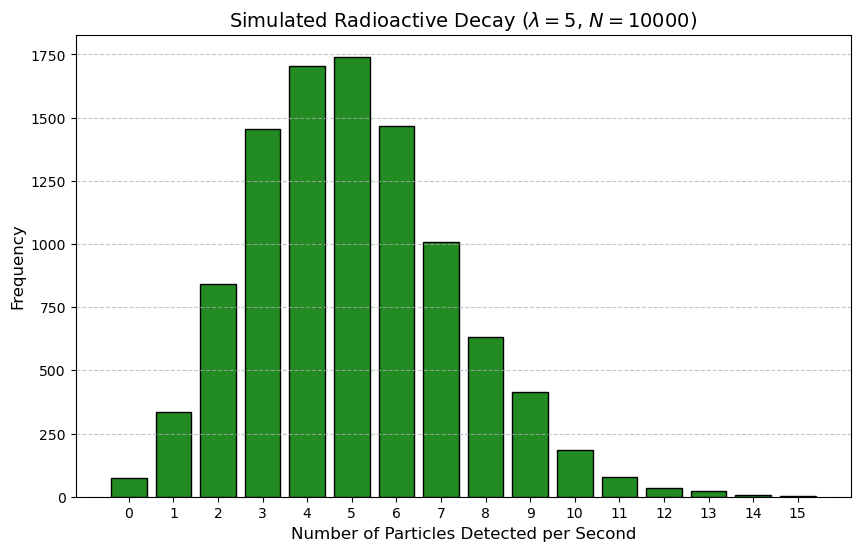

In [102]:
# 1. Initialize the Generator
rng = np.random.default_rng(seed=42)

# 2. Parameters
lam = 5.0          # Average counts per second
n_samples = 10000  # Number of seconds recorded

# 3. Generate the simulated counts
counts = rng.poisson(lam, n_samples) # YOUR CODE HERE

# 4. Statistical Check
print(f"Calculated Mean:", np.mean(counts))
print(f"Calculated Variance: {np.var(counts):.4f}")

# 5. Visualization
plt.figure(figsize=(10, 6))

# For discrete data, we center bins on integers
# We create bins at -0.5, 0.5, 1.5, etc.
bins = np.arange(0, np.max(counts) + 2) - 0.5

plt.hist(counts, bins=bins, color='forestgreen', edgecolor='black', rwidth=0.8)

# Add labels and title
plt.title(f"Simulated Radioactive Decay ($λ=5$, $N={n_samples}$)", fontsize=14)
plt.xlabel("Number of Particles Detected per Second", fontsize=12)
plt.ylabel("Frequency", fontsize=12)

# Set x-ticks to be exactly the integers for clarity
plt.xticks(np.arange(0, np.max(counts) + 1))

# Add a light grid for readability
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

**Solution**

rng.poisson(lam, n_samples)

## Conclusion: You’ve Mastered the Foundation\! 🚀

Congratulations\! You have successfully navigated the core pillars of **NumPy**, the most essential library in the Python scientific ecosystem.

As a physics student, you now have a powerful new "laboratory" on your computer. Instead of being limited by what you can calculate on a chalkboard, you can now:

  * **Handle massive datasets** from real-world experiments.
  * **Simulate complex physical systems** using vectorized operations.
  * **Solve linear systems** that would be impossible to do by hand.
  * **Model randomness and uncertainty**, which is at the heart of quantum mechanics and thermodynamics.

### Where do we go from here?

NumPy is the **foundation**, but it is rarely used alone. As you progress in your physics degree, you will likely encounter these "sibling" libraries that are built directly on top of NumPy:

1.  **SciPy (Scientific Python):** Think of this as "NumPy for Physicists." it contains built-in functions for integration, solving differential equations (like Schrödinger's or Maxwell's equations), and signal processing.
2.  **Matplotlib & Seaborn:** As we saw in the RNG section, these are your primary tools for turning raw numbers into the beautiful, publication-quality plots you see in textbooks.
3.  **Pandas:** The industry standard for handling tabular data (like large CSV files from a laboratory sensor or a particle collider).
4.  **SymPy:** If you ever get tired of doing messy algebraic derivations, SymPy allows you to do symbolic math (calculus, algebra) using Python code.

### Final Advice: "Vectorized Thinking"

The most important takeaway from this notebook isn't just a list of commands like `np.array()` or `np.mean()`. It is a **shift in mindset**.

In physics, we think in terms of fields, waves, and ensembles. NumPy allows your code to match that intuition. Whenever you find yourself writing a `for` loop to do math, stop and ask: **"Can I do this with a NumPy array instead?"** Usually, the answer is yes, and your code will be faster, cleaner, and more "physical" for it.

**Keep experimenting, keep simulating, and happy coding\!**

### Resources

  * [Official NumPy Documentation](https://numpy.org/doc/stable/user/absolute_beginners.html) - The best place to look up specific functions.
  * [Scientific Programming with Python](https://scipython.com/) - Christian Hill website